In [1]:
import pandas as pd

df = pd.DataFrame({
    "temperature":[10, 7, 4, 0],
    "sales": [30, 50, 60, 80]
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [2]:
a = -4
b = 80

for i in range(len(df)):
    x = df.loc[i, "temperature"]
    pred = a * x + b
    print(f"X={x}일 때 예측값 = {a} * {x} + {b} = {pred}")

X=10일 때 예측값 = -4 * 10 + 80 = 40
X=7일 때 예측값 = -4 * 7 + 80 = 52
X=4일 때 예측값 = -4 * 4 + 80 = 64
X=0일 때 예측값 = -4 * 0 + 80 = 80


In [3]:
a = -4
b = 80

for i in range(len(df)):
    x = df.loc[i, "temperature"]
    y = df.loc[i, "sales"]
    pred = a * x + b
    error = pred -y

    print(f"X={x}, 실제값={y}, 예측값={pred}, 오차={pred}-{y}={error}")
    print("="*30)

X=10, 실제값=30, 예측값=40, 오차=40-30=10
X=7, 실제값=50, 예측값=52, 오차=52-50=2
X=4, 실제값=60, 예측값=64, 오차=64-60=4
X=0, 실제값=80, 예측값=80, 오차=80-80=0


In [4]:
a = -4
b = 80

square_sum = 0

for i in range(len(df)):
    x = df.loc[i, "temperature"]
    y = df.loc[i, "sales"]
    pred = a * x + b
    error = pred - y
    error_square = error * error
    square_sum = square_sum + error_square

n = len(df)
cost = square_sum / n

print(f"오차 제곱 합: {square_sum}")
print(f"데이터 개수: {n}")
print(f"Cost: {cost:.4f}")


오차 제곱 합: 120
데이터 개수: 4
Cost: 30.0000


In [5]:
def calculate_cost(a, b):
    n = len(df)
    # print(f"n={n}")
    square_sum = 0
    
    for i in range(n):
        x = df.loc[i, "temperature"]
        y = df.loc[i, "sales"]
        # print(f"x={x}, y={y}")

        pred = a * x + b
        # print(f"pred={pred}")

        error = y - pred
        # print(f"error={error}")

        error_square = error * error
        # print(f"error_square={error_square}")

        square_sum = square_sum + error_square
        # print(f"square_sum={square_sum}")
    
    n = len(df)
    cost = square_sum /n
    return cost

print("calculate_cost(-4, 80) =", calculate_cost(-4, 80))

calculate_cost(-4, 80) = 30.0


In [6]:
cost1 = calculate_cost(-4, 80)
cost2 = calculate_cost(-4.9, 81)

print(f"Y = -4X + 80 의 Cost: {cost1:.4f}")
print(f"Y = -4.9X + 81 의 Cost: {cost2:.4f}")

Y = -4X + 80 의 Cost: 30.0000
Y = -4.9X + 81 의 Cost: 4.4625


In [7]:
a_values = [-6, -5, -4, -3, -2]
b = 80

cost_values = []

for a in a_values:
    cost = calculate_cost(a, b)
    cost_values.append(cost)
    print(f"a={a}, b={b}, Cost={cost:.4f}")

a=-6, b=80, Cost=65.0000
a=-5, b=80, Cost=6.2500
a=-4, b=80, Cost=30.0000
a=-3, b=80, Cost=136.2500
a=-2, b=80, Cost=325.0000


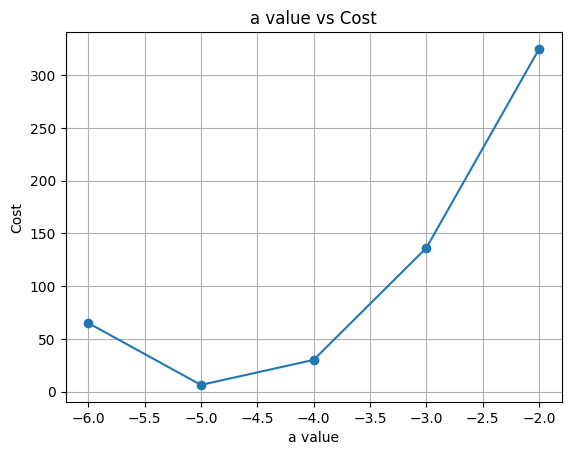

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(a_values, cost_values, marker='o')
plt.title("a value vs Cost")
plt.xlabel("a value")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

In [9]:
b = 80

a = -4
cost = calculate_cost(a, b)
print(f"a={a}, b={b}, Cost={cost:.4f}")

a = -4.5
cost = calculate_cost(a, b)
print(f"a={a}, b={b}, Cost={cost:.4f}")

a = -5
cost = calculate_cost(a, b)
print(f"a={a}, b={b}, Cost={cost:.4f}")

a=-4, b=80, Cost=30.0000
a=-4.5, b=80, Cost=7.8125
a=-5, b=80, Cost=6.2500


In [15]:
a = -4
b = 80
learning_rate = 0.001
epochs = 10000

n = len(df)
cost_history = []

initial_a = a
initial_b = b
initial_cost = calculate_cost(a, b)
print(f"학습 전 Cost: {initial_cost:.4f}")

학습 전 Cost: 30.0000


In [16]:
for epoch in range(epochs):
    grad_a = 0
    grad_b = 0

    for i in range(len(df)):
        x = df.loc[i, "temperature"]
        y = df.loc[i, "sales"]

        pred = a * x + b
        pred_minus_actual = pred - y

        grad_a = grad_a + pred_minus_actual * x
        grad_b = grad_b + pred_minus_actual

    n = len(df)
    grad_a = grad_a / n
    grad_b = grad_b / n

    a = a - learning_rate * grad_a
    b = b - learning_rate * grad_b

    cost = calculate_cost(a, b)
    cost_history.append(cost)

    if epoch % 100 == 0:
        print(f"epoch={epoch}, Cost={cost:.4f}, a={a:.4f}, b={b:.4f}")


epoch=0, Cost=27.9005, a=-4.0325, b=79.9960
epoch=100, Cost=4.4233, a=-4.7666, b=79.9185
epoch=200, Cost=4.4137, a=-4.7787, b=79.9331
epoch=300, Cost=4.4089, a=-4.7808, b=79.9484
epoch=400, Cost=4.4044, a=-4.7827, b=79.9632
epoch=500, Cost=4.4002, a=-4.7846, b=79.9776
epoch=600, Cost=4.3963, a=-4.7864, b=79.9916
epoch=700, Cost=4.3926, a=-4.7881, b=80.0050
epoch=800, Cost=4.3891, a=-4.7898, b=80.0181
epoch=900, Cost=4.3859, a=-4.7914, b=80.0307
epoch=1000, Cost=4.3829, a=-4.7930, b=80.0429
epoch=1100, Cost=4.3800, a=-4.7945, b=80.0547
epoch=1200, Cost=4.3773, a=-4.7960, b=80.0662
epoch=1300, Cost=4.3749, a=-4.7974, b=80.0773
epoch=1400, Cost=4.3725, a=-4.7987, b=80.0880
epoch=1500, Cost=4.3703, a=-4.8001, b=80.0984
epoch=1600, Cost=4.3683, a=-4.8014, b=80.1084
epoch=1700, Cost=4.3664, a=-4.8026, b=80.1181
epoch=1800, Cost=4.3646, a=-4.8038, b=80.1275
epoch=1900, Cost=4.3629, a=-4.8050, b=80.1366
epoch=2000, Cost=4.3613, a=-4.8061, b=80.1454
epoch=2100, Cost=4.3598, a=-4.8072, b=80.1540

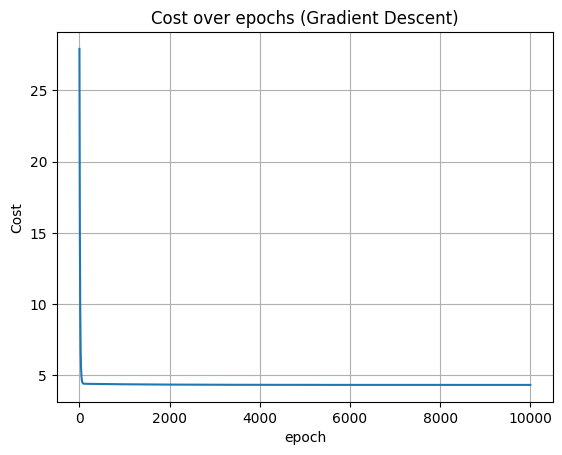

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(len(cost_history)), cost_history)
plt.title("Cost over epochs (Gradient Descent)")
plt.xlabel("epoch")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

In [18]:
final_a = a
final_b = b
final_cost = calculate_cost(final_a, final_b)

print("학습 전")
print(f"a = {initial_a:.4f}")
print(f"b = {initial_b:.4f}")
print(f"Cost = {initial_cost:.4f}")

print("학습 전")
print(f"a = {final_a:.4f}")
print(f"b = {final_b:.4f}")
print(f"Cost = {final_cost:.4f}")

학습 전
a = -4.0000
b = 80.0000
Cost = 30.0000
학습 전
a = -4.8377
b = 80.3915
Cost = 4.3380
